# Phase 2: 10-Class MNIST Classification — Gradient Boosting
## Pipeline: Data Loading -> Preprocessing -> Feature Extraction -> Training -> Learning Curves -> Evaluation

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from ml_utils import train_test_split, StandardScaler
from ml_utils import classification_report, confusion_matrix
from ml_utils import compute_accuracy, k_fold_split, cross_validate
from ml_utils import plot_learning_curve, evaluate_model, show_misclassified
from sklearn.decomposition import PCA
from skimage.feature import hog
np.random.seed(42)
print("Libraries imported")

Libraries imported


## 2. Configuration

In [2]:
NUM_CLASSES = 10
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15
PCA_VARIANCE = 0.95
K_FOLDS = 5
LC_FRACTIONS = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
GB_N_ESTIMATORS = 30
GB_MAX_DEPTH = 3
GB_LEARNING_RATE = 0.1

## 3. Data Loading & Preprocessing

In [3]:
X_train_raw = np.load('../../mnist.npz/x_train.npy')
y_train_raw = np.load('../../mnist.npz/y_train.npy')
X_test_raw  = np.load('../../mnist.npz/x_test.npy')
y_test_raw  = np.load('../../mnist.npz/y_test.npy')
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

min_count = min(np.bincount(y_all))
balanced_idx = []
for c in range(NUM_CLASSES):
    c_idx = np.where(y_all == c)[0]
    np.random.shuffle(c_idx)
    balanced_idx.extend(c_idx[:min_count])
balanced_idx = np.array(balanced_idx)
np.random.shuffle(balanced_idx)
X_balanced, y_balanced = X_all[balanced_idx], y_all[balanced_idx]
X_norm = X_balanced / 255.0

X_temp, X_test, y_temp, y_test = train_test_split(
    X_norm, y_balanced, test_size=TEST_SIZE/(TRAIN_SIZE+VAL_SIZE+TEST_SIZE),
    random_state=42, stratify=y_balanced)
val_adj = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_adj, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 44190, Val: 9470, Test: 9470


### Visualise Dataset Samples
One example per class from the training set.

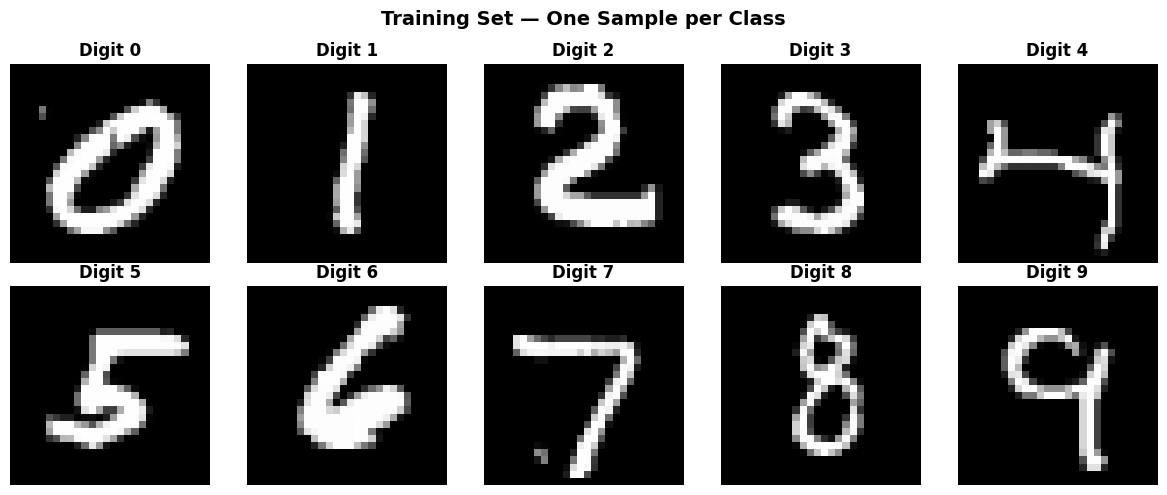

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c in range(NUM_CLASSES):
    r, col = divmod(c, 5)
    idx = np.where(y_train == c)[0][0]
    axes[r, col].imshow(X_train[idx], cmap='gray')
    axes[r, col].set_title(f'Digit {c}', fontweight='bold')
    axes[r, col].axis('off')
plt.suptitle('Training Set — One Sample per Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4a. Flatten + Scaler + PCA Feature Extraction

In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_val_sc = scaler.transform(X_val_flat)
X_test_sc = scaler.transform(X_test_flat)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca = pca.transform(X_val_sc)
X_test_pca = pca.transform(X_test_sc)
print(f"PCA: {X_train_sc.shape[1]} -> {X_train_pca.shape[1]} components ({np.sum(pca.explained_variance_ratio_):.4f} var)")

PCA: 784 -> 324 components (0.9503 var)


### Visualise PCA

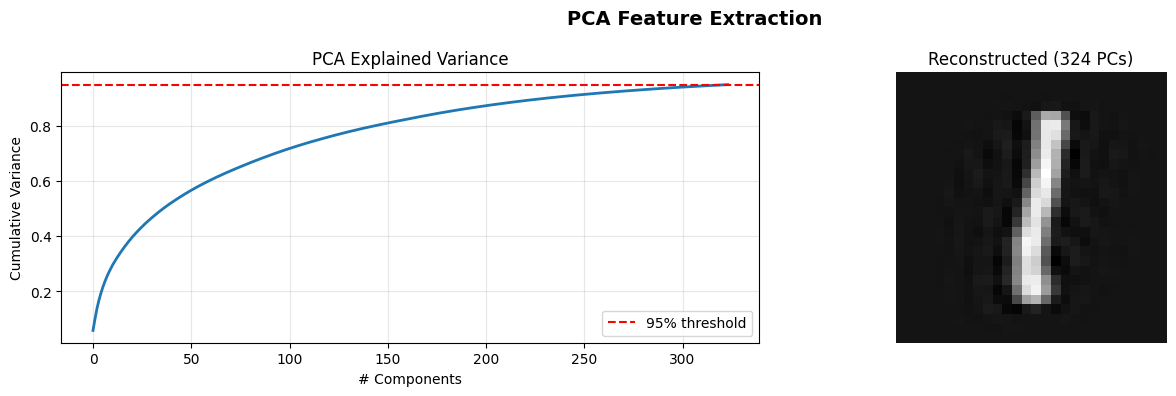

In [6]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cum_var, linewidth=2)
axes[0].axhline(PCA_VARIANCE, ls='--', color='red', label=f'{PCA_VARIANCE:.0%} threshold')
axes[0].set_xlabel('# Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('PCA Explained Variance'); axes[0].legend(); axes[0].grid(alpha=.3)

recon = pca.inverse_transform(X_train_pca[0:1])
recon = scaler.inverse_transform(recon).reshape(28, 28)
axes[1].imshow(recon, cmap='gray')
axes[1].set_title(f'Reconstructed ({X_train_pca.shape[1]} PCs)'); axes[1].axis('off')
plt.suptitle('PCA Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4b. HOG Feature Extraction

**Histogram of Oriented Gradients** captures edge and gradient structure.
Applied to the 2D images (before flattening), then standardised.

In [7]:
def extract_hog(images):
    feats = []
    for img in images:
        f = hog(img, orientations=9, pixels_per_cell=(4,4),
                cells_per_block=(2,2), block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

X_train_hog = extract_hog(X_train)
X_val_hog   = extract_hog(X_val)
X_test_hog  = extract_hog(X_test)

scaler_hog = StandardScaler()
X_train_hog_sc = scaler_hog.fit_transform(X_train_hog)
X_val_hog_sc   = scaler_hog.transform(X_val_hog)
X_test_hog_sc  = scaler_hog.transform(X_test_hog)

print(f"HOG feature dim: {X_train_hog_sc.shape[1]}")
print("HOG features ready")

HOG feature dim: 1296
HOG features ready


### Visualise HOG Features

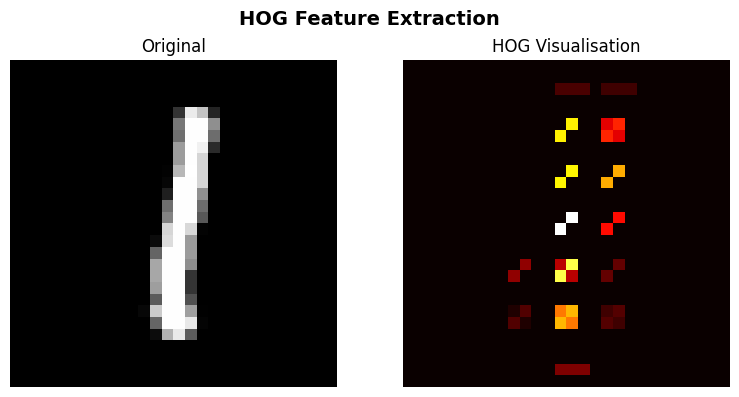

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0], cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
_, hog_img = hog(X_train[0], orientations=9, pixels_per_cell=(4,4),
                 cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
axes[1].imshow(hog_img, cmap='hot')
axes[1].set_title('HOG Visualisation'); axes[1].axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Regression Tree 

A shallow regression tree that minimises **MSE** at each split.
Used as the weak learner inside the Gradient Boosting ensemble.

In [9]:
class RegressionTree:
    def __init__(self, max_depth=3, min_samples_split=4):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree_ = None

    @staticmethod
    def _mse_split(y_left, y_right):
        n = len(y_left) + len(y_right)
        mse = 0.0
        if len(y_left) > 0:
            mse += len(y_left) * np.var(y_left)
        if len(y_right) > 0:
            mse += len(y_right) * np.var(y_right)
        return mse / n

    def _best_split(self, X, y):
        n, d = X.shape
        if n < self.min_samples_split:
            return None, None

        best_mse = np.var(y)  # parent MSE
        best_feat, best_thresh = None, None

        for feat in range(d):
            vals = X[:, feat]
            thresholds = np.unique(np.percentile(vals, np.linspace(10, 90, 10)))
            for thresh in thresholds:
                mask = vals <= thresh
                if np.sum(mask) == 0 or np.sum(~mask) == 0:
                    continue
                mse = self._mse_split(y[mask], y[~mask])
                if mse < best_mse:
                    best_mse = mse
                    best_feat = feat
                    best_thresh = thresh
        return best_feat, best_thresh

    def _build(self, X, y, depth):
        val = float(np.mean(y))
        if depth >= self.max_depth or len(y) < self.min_samples_split or np.var(y) < 1e-10:
            return val  # leaf

        feat, thresh = self._best_split(X, y)
        if feat is None:
            return val

        mask = X[:, feat] <= thresh
        left  = self._build(X[mask],  y[mask],  depth + 1)
        right = self._build(X[~mask], y[~mask], depth + 1)
        return (feat, thresh, left, right)

    def fit(self, X, y):
        self.tree_ = self._build(X, y.astype(float), 0)
        return self

    def _traverse(self, x, node):
        if not isinstance(node, tuple):
            return node
        feat, thresh, left, right = node
        return self._traverse(x, left if x[feat] <= thresh else right)

    def predict(self, X):
        return np.array([self._traverse(x, self.tree_) for x in X])

## 6. Gradient Boosting Classifier 

**Algorithm (multiclass with softmax):**
1. Initialise $F_k(x)=0$ for each class $k$.
2. For each boosting round $m$:
   - Compute probabilities $p_k = \text{softmax}(F_k)$
   - For each class $k$: fit a regression tree to residuals $r_k = y_k^{onehot} - p_k$
   - Update $F_k \mathrel{+}= \eta \cdot \text{tree}_k(x)$
3. Predict $\arg\max_k\; \text{softmax}(F_k)$

In [10]:
class GradientBoostingClassifier:
    def __init__(self, n_estimators=30, max_depth=3, learning_rate=0.1, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.lr = learning_rate
        self.random_state = random_state
        self.trees_ = []

    @staticmethod
    def _softmax(z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        n = len(y)

        # One-hot encode
        y_oh = np.zeros((n, K))
        for i, c in enumerate(self.classes_):
            y_oh[y == c, i] = 1.0

        F = np.zeros((n, K))  # raw scores
        self.trees_ = []

        for m in range(self.n_estimators):
            probs = self._softmax(F)
            residuals = y_oh - probs  # negative gradient

            round_trees = []
            for k in range(K):
                tree = RegressionTree(max_depth=self.max_depth)
                tree.fit(X, residuals[:, k])
                F[:, k] += self.lr * tree.predict(X)
                round_trees.append(tree)
            self.trees_.append(round_trees)

            if (m + 1) % 5 == 0 or m == 0:
                train_pred = self.classes_[np.argmax(self._softmax(F), axis=1)]
                acc = np.mean(train_pred == y)
                print(f"  Round {m+1}/{self.n_estimators} — train acc: {acc:.4f}")
        return self

    def predict(self, X):
        K = len(self.classes_)
        F = np.zeros((len(X), K))
        for round_trees in self.trees_:
            for k in range(K):
                F[:, k] += self.lr * round_trees[k].predict(X)
        return self.classes_[np.argmax(self._softmax(F), axis=1)]

## 7. Training (PCA Features)

TRAINING GRADIENT BOOSTING (From Scratch)
  Round 1/30 — train acc: 0.6958
  Round 5/30 — train acc: 0.7007
  Round 10/30 — train acc: 0.7056
  Round 15/30 — train acc: 0.7098
  Round 20/30 — train acc: 0.7138
  Round 25/30 — train acc: 0.7222
  Round 30/30 — train acc: 0.7264

Gradient Boosting (From Scratch) — Test Acc: 0.7134 (71.34%)
                 precision     recall   f1-score    support

        Digit 0       0.81       0.78       0.80        947
        Digit 1       0.85       0.89       0.87        947
        Digit 2       0.75       0.69       0.72        947
        Digit 3       0.72       0.70       0.71        947
        Digit 4       0.62       0.67       0.64        947
        Digit 5       0.64       0.53       0.58        947
        Digit 6       0.78       0.86       0.82        947
        Digit 7       0.79       0.71       0.75        947
        Digit 8       0.63       0.65       0.64        947
        Digit 9       0.56       0.66       0.61        947

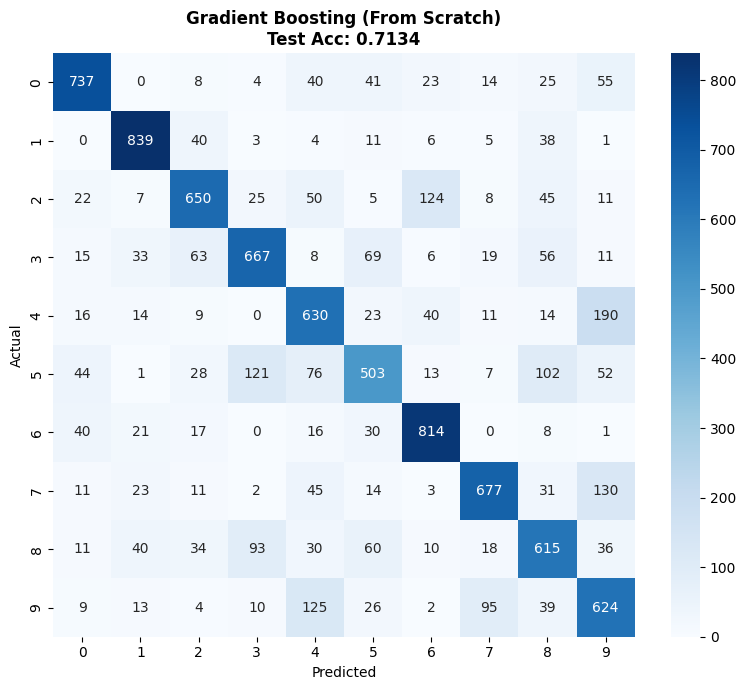

In [11]:
print("=" * 70)
print("TRAINING GRADIENT BOOSTING (From Scratch)")
print("=" * 70)
gb = GradientBoostingClassifier(n_estimators=GB_N_ESTIMATORS, max_depth=GB_MAX_DEPTH,
                                 learning_rate=GB_LEARNING_RATE, random_state=42)
gb.fit(X_train_pca, y_train)
gb_acc = evaluate_model(gb, X_test_pca, y_test, "Gradient Boosting (From Scratch)")

Misclassified: 2714 / 9470


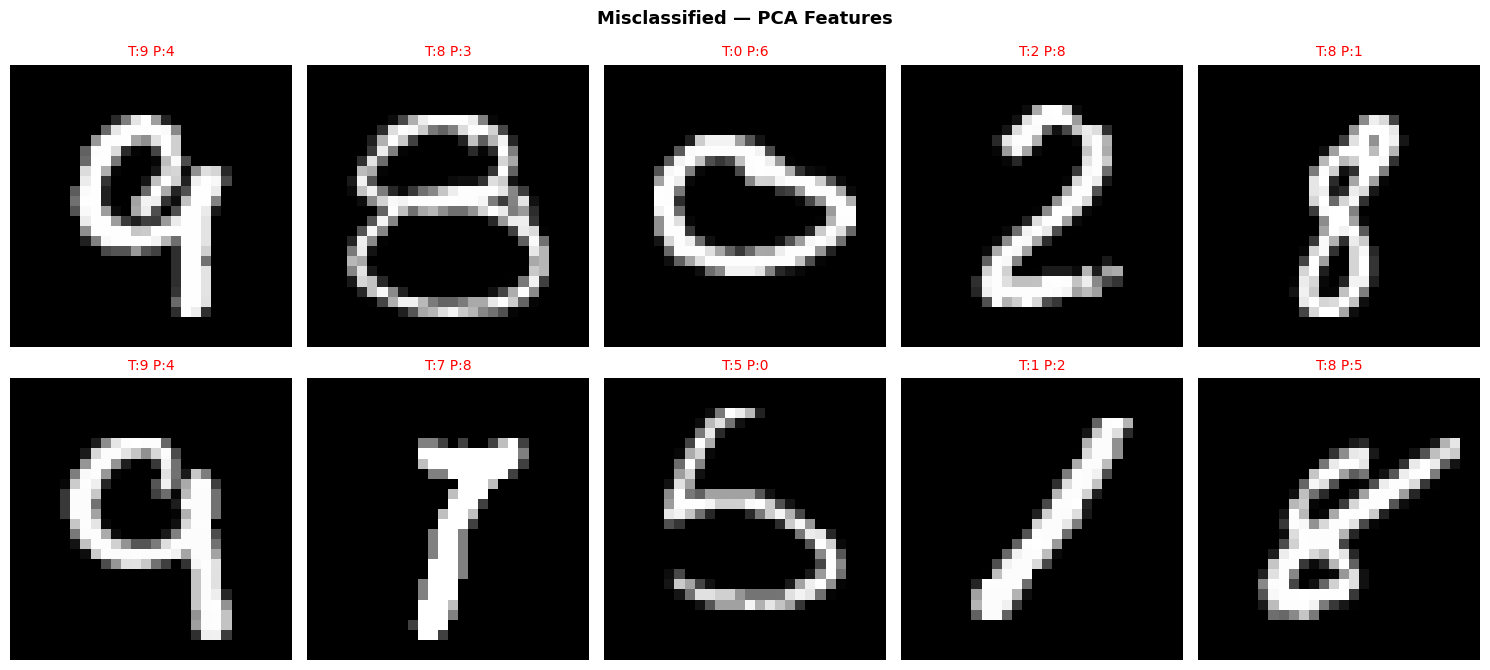

In [12]:
# Note: showing original images for misclassified PCA predictions
preds_pca = gb.predict(X_test_pca)
show_misclassified(y_test, preds_pca, X_test,
                   title='Misclassified — PCA Features')

### Gradient Boosting — Flatten Features


Gradient Boosting — Flatten Features
  Round 1/30 — train acc: 0.6868
  Round 5/30 — train acc: 0.7134
  Round 10/30 — train acc: 0.7473
  Round 15/30 — train acc: 0.7659
  Round 20/30 — train acc: 0.7831
  Round 25/30 — train acc: 0.7920
  Round 30/30 — train acc: 0.7983

Gradient Boosting (Flatten) — Test Acc: 0.7952 (79.52%)
                 precision     recall   f1-score    support

        Digit 0       0.85       0.92       0.88        947
        Digit 1       0.79       0.92       0.85        947
        Digit 2       0.84       0.75       0.80        947
        Digit 3       0.75       0.76       0.75        947
        Digit 4       0.75       0.82       0.79        947
        Digit 5       0.83       0.66       0.74        947
        Digit 6       0.86       0.85       0.86        947
        Digit 7       0.85       0.76       0.80        947
        Digit 8       0.73       0.75       0.74        947
        Digit 9       0.72       0.76       0.74        947

       

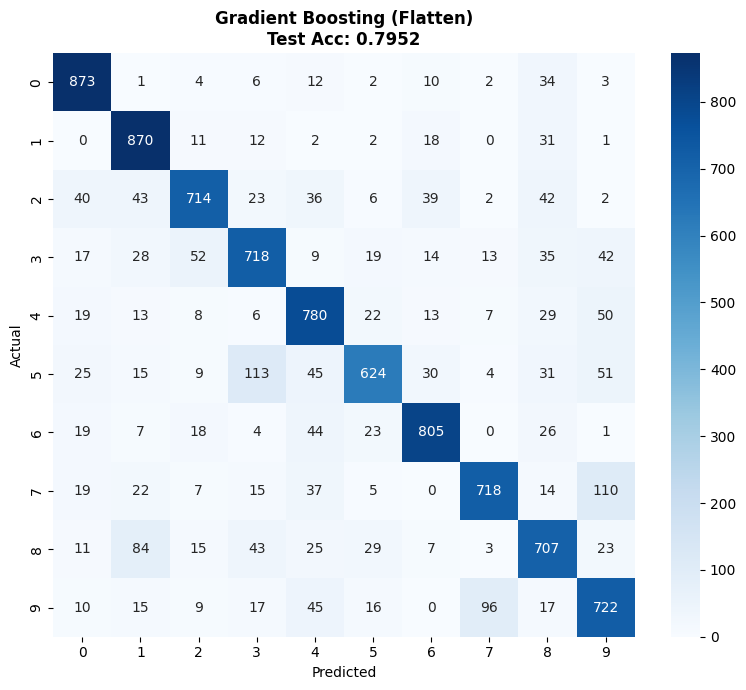

np.float64(0.7952481520591341)

In [13]:
print("\n" + "="*70)
print("Gradient Boosting — Flatten Features")
print("="*70)
model_flatten = GradientBoostingClassifier(n_estimators=GB_N_ESTIMATORS, max_depth=GB_MAX_DEPTH, learning_rate=GB_LEARNING_RATE, random_state=42)
model_flatten.fit(X_train_sc, y_train)
evaluate_model(model_flatten, X_test_sc, y_test, "Gradient Boosting (Flatten)")

Misclassified: 1939 / 9470


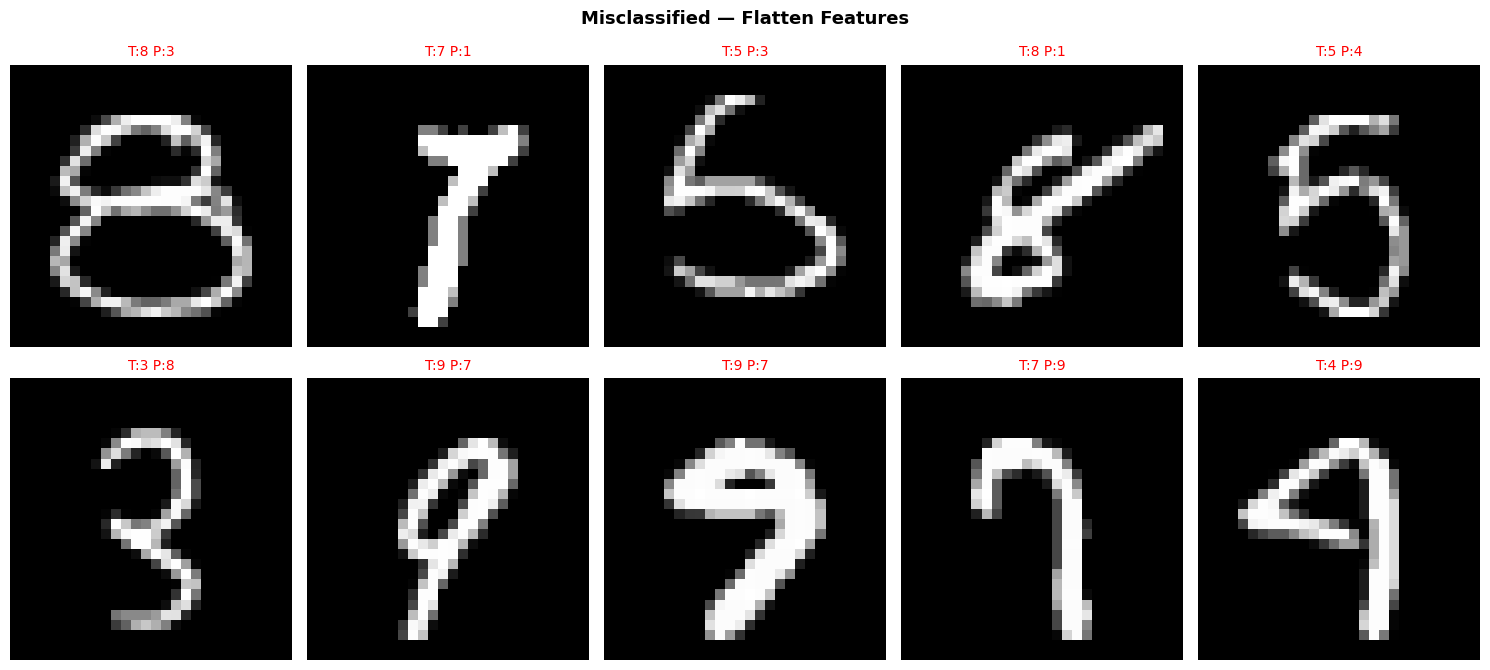

In [14]:
# Note: showing original images for misclassified Flatten predictions
preds_flatten = model_flatten.predict(X_test_sc)
show_misclassified(y_test, preds_flatten, X_test,
                   title='Misclassified — Flatten Features')

### Gradient Boosting — HOG Features


Gradient Boosting — HOG Features
  Round 1/30 — train acc: 0.7831
  Round 5/30 — train acc: 0.8060
  Round 10/30 — train acc: 0.8186
  Round 15/30 — train acc: 0.8306
  Round 20/30 — train acc: 0.8403
  Round 25/30 — train acc: 0.8497
  Round 30/30 — train acc: 0.8559

Gradient Boosting (HOG) — Test Acc: 0.8520 (85.20%)
                 precision     recall   f1-score    support

        Digit 0       0.88       0.90       0.89        947
        Digit 1       0.93       0.91       0.92        947
        Digit 2       0.84       0.85       0.84        947
        Digit 3       0.82       0.82       0.82        947
        Digit 4       0.87       0.81       0.84        947
        Digit 5       0.84       0.89       0.87        947
        Digit 6       0.89       0.85       0.87        947
        Digit 7       0.91       0.84       0.87        947
        Digit 8       0.78       0.80       0.79        947
        Digit 9       0.77       0.85       0.81        947

       accuracy

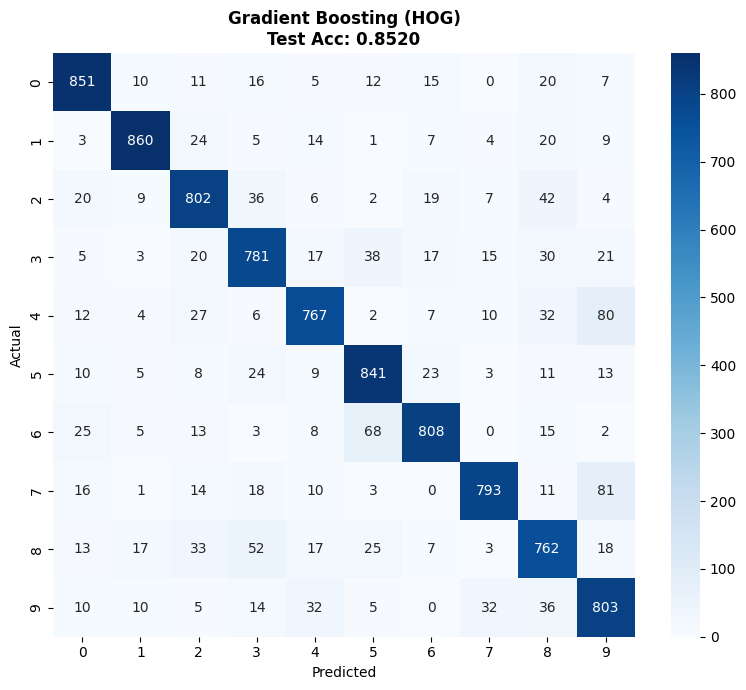

np.float64(0.8519535374868005)

In [15]:
print("\n" + "="*70)
print("Gradient Boosting — HOG Features")
print("="*70)
model_hog = GradientBoostingClassifier(n_estimators=GB_N_ESTIMATORS, max_depth=GB_MAX_DEPTH, learning_rate=GB_LEARNING_RATE, random_state=42)
model_hog.fit(X_train_hog_sc, y_train)
evaluate_model(model_hog, X_test_hog_sc, y_test, "Gradient Boosting (HOG)")

Misclassified: 1402 / 9470


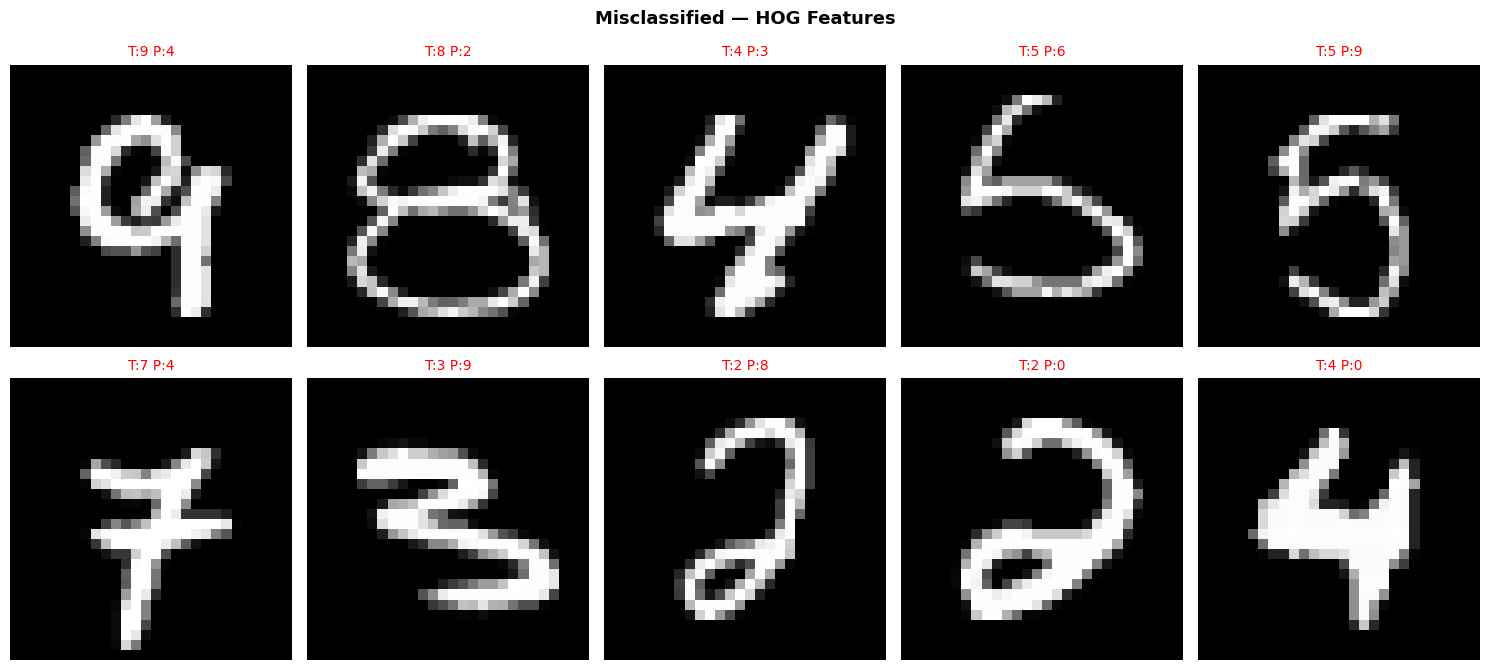

In [16]:
# Note: showing original images for misclassified HOG predictions
preds_hog = model_hog.predict(X_test_hog_sc)
show_misclassified(y_test, preds_hog, X_test,
                   title='Misclassified — HOG Features')

## 8. Learning Curve

  Round 1/15 — train acc: 0.6852
  Round 5/15 — train acc: 0.6879
  Round 10/15 — train acc: 0.7146
  Round 15/15 — train acc: 0.7266
  Round 1/15 — train acc: 0.6881
  Round 5/15 — train acc: 0.6907
  Round 10/15 — train acc: 0.6999
  Round 15/15 — train acc: 0.7134
  Round 1/15 — train acc: 0.6946
  Round 5/15 — train acc: 0.7034
  Round 10/15 — train acc: 0.7066
  Round 15/15 — train acc: 0.7146
  Round 1/15 — train acc: 0.6944
  Round 5/15 — train acc: 0.6956
  Round 10/15 — train acc: 0.6995
  Round 15/15 — train acc: 0.7081
  Round 1/15 — train acc: 0.6976
  Round 5/15 — train acc: 0.6988
  Round 10/15 — train acc: 0.7029
  Round 15/15 — train acc: 0.7091
  Round 1/15 — train acc: 0.6958
  Round 5/15 — train acc: 0.7007
  Round 10/15 — train acc: 0.7056
  Round 15/15 — train acc: 0.7098


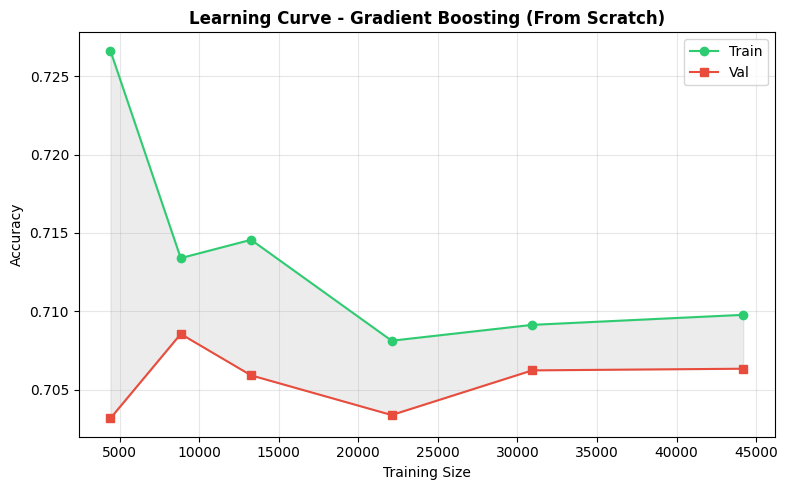

In [17]:
plot_learning_curve(GradientBoostingClassifier,
                    {'n_estimators': 15, 'max_depth': GB_MAX_DEPTH,
                     'learning_rate': GB_LEARNING_RATE, 'random_state': 42},
                    X_train_pca, y_train, X_val_pca, y_val, LC_FRACTIONS,
                    "Learning Curve - Gradient Boosting (From Scratch)")

## 9. Summary

**Analysis**: Gradient Boosting sequentially builds weak learners (shallow
regression trees), each correcting the errors of the ensemble so far.
The `learning_rate` shrinks each tree's contribution to prevent overfitting.
Smaller `max_depth` increases bias but reduces variance; more `n_estimators`
reduce bias but risk overfitting if `learning_rate` is too large.